Data-Driven Crash Severity Analysis using Machine Learning, SHAP Explainability, Association Rule Mining, and Crash Archetype Clustering"

Removing warning signs

In [1]:
import warnings

# Filter out all DeprecationWarnings from the 'jupyter_client' module
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')
# Filter out the specific DeprecationWarning regarding datetime.utcnow()
warnings.filterwarnings("ignore", message="datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).", category=DeprecationWarning)

print("DeprecationWarnings from jupyter_client have been filtered.")

DeprecationWarnings from jupyter_client have been filtered.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# IMPORTANT: Replace '/content/drive/MyDrive/path/to/your/file.csv' with the actual path to your CSV file.
df = pd.read_csv('/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv')

print('CSV file loaded successfully.')

/tmp/ipython-input-3130583188.py:4: DtypeWarning: Columns (35,36,55,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv')


CSV file loaded successfully.


**Vehicle-Level Severity Target Creation & Feature Selection**

Create Target Variable:

1.   A new binary column severity_bin is generated, where a value of 1 indicates that the vehicle had at least one fatality (DEATHS > 0), and 0 means no fatality.

Remove ID / Leakage Columns:
1.   Columns such as case IDs, person/vehicle numbers, ZIP codes, timestamps of death, raw manufacturer/model fields, and other identifiers are removed to avoid data leakage and ensure the model learns only meaningful crash patterns.

Select Relevant Predictors:
1.   A curated set of features is chosen from vehicle characteristics, roadway/environment conditions, and driver behavior/history. Only features actually present in the dataset are kept.

Prepare Feature Matrix and Labels:
1.   Rows with missing target values are dropped, and the remaining data is split into feature matrix X and target vector y.

Train-Test Split:
1.   The dataset is split into training (80%) and testing (20%) sets with stratification, ensuring the fatal vs non-fatal distribution remains consistent across both sets.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Create a vehicle-level severity target (0 = no fatality, 1 = any fatality)
df['severity_bin'] = (df['DEATHS'] > 0).astype(int)

# 2. Drop obviously ID-like columns and those that leak target information
id_columns_to_drop = [
    'ST_CASE', 'VEH_NO', 'PER_NO', 'DR_ZIP', 'DR_ZIPNAME', 'PERSON_SOURCE',
    'FATALS', 'INJ_SEVNAME', 'DEATH_MONAME', 'DEATH_DANAME', 'DEATH_YRNAME',
    'DEATH_TMNAME', 'DEATH_HRNAME', 'DEATH_MNNAME', 'DOANAME', 'MAKE', 'MODEL',
    'VPICMAKENAME', 'VPICMODELNAME'
]

# Filter out columns that might not exist in df for robustness
id_columns_to_drop = [col for col in id_columns_to_drop if col in df.columns]

df = df.drop(columns=id_columns_to_drop, errors='ignore')

# 3. Select a clean subset of features for modeling
selected_features = [
    # Vehicle
    'BODY_TYPNAME', 'V_CONFIGNAME', 'GVWR_FROMNAME', 'GVWR_TONAME', 'TRAV_SPNAME',
    'ROLLOVERNAME', 'ROLINLOCNAME', 'IMPACT1NAME', 'DEFORMEDNAME', 'TOWEDNAME',
    # Road & environment
    'VTRAFWAYNAME', 'VNUM_LANNAME', 'VSPD_LIMNAME', 'VALIGNNAME', 'VPROFILENAME',
    'VPAVETYPNAME', 'VSURCONDNAME', 'VTRAFCONNAME', 'LGT_CONDNAME', 'WEATHERNAME',
    'RUR_URBNAME', 'FUNC_SYSNAME',
    # Driver & history
    'AGE', 'SEXNAME', 'DRINKINGNAME', 'DRUGSNAME', 'PREV_ACCNAME',
    'PREV_DWINAME', 'PREV_SPDNAME', 'PREV_OTHNAME'
]

# Ensure only existing columns from selected_features are kept
final_features = [f for f in selected_features if f in df.columns]

# 4. Split into X (features) and y (`severity_bin`)
df_cleaned = df.dropna(subset=['severity_bin']).copy() # Drop rows with missing target
X = df_cleaned[final_features]
y = df_cleaned['severity_bin']

# 5. Do a simple train/test split with stratification (e.g., 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Feature Preprocessing — One-Hot Encoding & Column Sanitization**

1.   Identify Categorical Features:
Detect all columns in the training set that contain categorical or string values, since these cannot be fed directly into machine-learning models.

2.   Initialize One-Hot Encoder:
A OneHotEncoder is created to convert categorical variables into numeric indicator columns. Unknown categories in the test set are safely ignored.

3.   Fit Encoder on Training Data:
The encoder learns all category levels from the training data only (to prevent data leakage).

4.   Transform Train & Test Sets:
Both training and test categorical columns are converted into one-hot encoded numeric arrays.

5.   Create DataFrames with Encoded Features:
The encoded arrays are converted to DataFrames with appropriate feature names, aligned with the original row indices.

6.   Separate Numeric Columns:
Numeric (non-categorical) columns are kept as-is by dropping categorical columns from X_train and X_test.

7.   Combine Encoded + Numeric Features:
The processed numeric and encoded categorical features are horizontally concatenated to form fully numeric training and test matrices.

8.   Sanitize Column Names:
A custom function cleans the column names by removing invalid characters so they are compatible with XGBoost and other ML libraries.

9.   Final Processed Matrices:
The cleaned and encoded matrices (X_train_processed and X_test_processed) are now fully numeric, machine-learning-ready inputs for model training.

In [5]:
from sklearn.preprocessing import OneHotEncoder
import re
import pandas as pd

# --- Feature Preprocessing: One-Hot Encoding and Column Name Sanitization ---

# 1. Identify all columns in X_train that have an object or category data type
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# 2. Initialize a OneHotEncoder object
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 3. Fit the OneHotEncoder on the categorical_cols from X_train
ohe.fit(X_train[categorical_cols])

# 4. Transform the categorical_cols in both X_train and X_test
X_train_encoded = ohe.transform(X_train[categorical_cols])
X_test_encoded = ohe.transform(X_test[categorical_cols])

# 5. Get the new feature names generated by the encoder
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)

# 6. Convert the transformed NumPy arrays into Pandas DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# 7. Create new DataFrames by dropping the original categorical_cols
X_train_numeric = X_train.drop(columns=categorical_cols)
X_test_numeric = X_test.drop(columns=categorical_cols)

# 8. Concatenate the X_train_numeric and X_train_encoded_df DataFrames horizontally
X_train_processed = pd.concat([X_train_numeric, X_train_encoded_df], axis=1)

# 9. Concatenate the X_test_numeric and X_test_encoded_df DataFrames horizontally
X_test_processed = pd.concat([X_test_numeric, X_test_encoded_df], axis=1)

# 10. Sanitize column names for XGBoost compatibility
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        # Replace [, ], < with _
        new_col = re.sub(r'\[|\]|<', '_', col)
        # Remove any other non-alphanumeric chars (except underscores)
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', new_col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_processed = sanitize_col_names(X_train_processed.copy())
X_test_processed = sanitize_col_names(X_test_processed.copy())

**Model Training & Evaluation**

1.   Initialize XGBoost Classifier:
An XGBoost model is configured for binary classification (severity_bin), using tuned hyperparameters such as 500 trees, depth 6, learning rate 0.1, and log-loss evaluation.

2.   Train the Model:
The classifier is trained on the fully preprocessed training data (X_train_processed, y_train), learning patterns that distinguish fatal vs. non-fatal vehicle outcomes.

3.   Generate Predictions:
  The model produces:

    y_pred → predicted class (0 or 1)

    y_proba → predicted probability of fatality

4.   Evaluate Performance:
Multiple metrics are computed to assess accuracy and robustness:

      1. Accuracy

      2. Precision

      3. Recall

      4. F1 Score

5. ROC AUC Score (discrimination ability)

6.   Visualize Confusion Matrix:
A heatmap is generated to show the count of correct/incorrect predictions across the two classes.

7.   Extract Feature Importance:
XGBoost’s built-in feature importance scores are retrieved and displayed to identify which crash, vehicle, or road attributes contribute most to severity prediction.

8.   Plot Top Features:
A bar chart visualizes the top 20 most influential features, helping interpret which factors drive fatal vs. non-fatal outcomes.


Training XGBoost model with one-hot encoded data...
Model training complete.

--- Model Evaluation ---
Accuracy: 0.8624
Precision: 0.8497
Recall: 0.8631
F1 Score: 0.8564
ROC AUC Score: 0.9427

--- Confusion Matrix ---


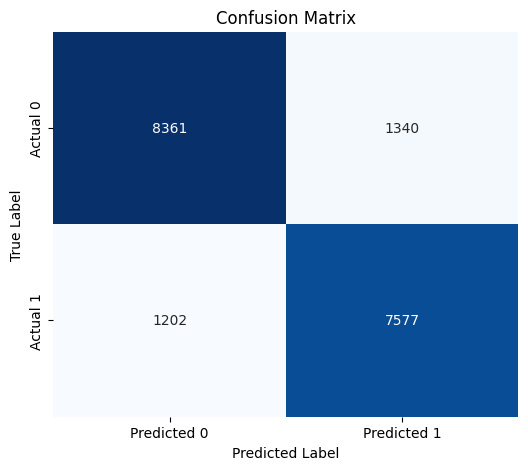


--- Feature Importance ---
                                           Feature  Importance
297                                TOWEDNAME_Towed    0.203766
244                        ROLLOVERNAME_NoRollover    0.061278
250                        ROLINLOCNAME_NoRollover    0.053331
287                   DEFORMEDNAME_DisablingDamage    0.031230
286       DEFORMEDNAME_DamageReportedExtentUnknown    0.023025
245                     ROLLOVERNAME_NotApplicable    0.019879
275                       IMPACT1NAME_NonCollision    0.018956
78                                V_CONFIGNAME_nan    0.014765
79   GVWR_FROMNAME_Class16000lbsorless2722kgorless    0.014449
66                      V_CONFIGNAME_NotApplicable    0.012745


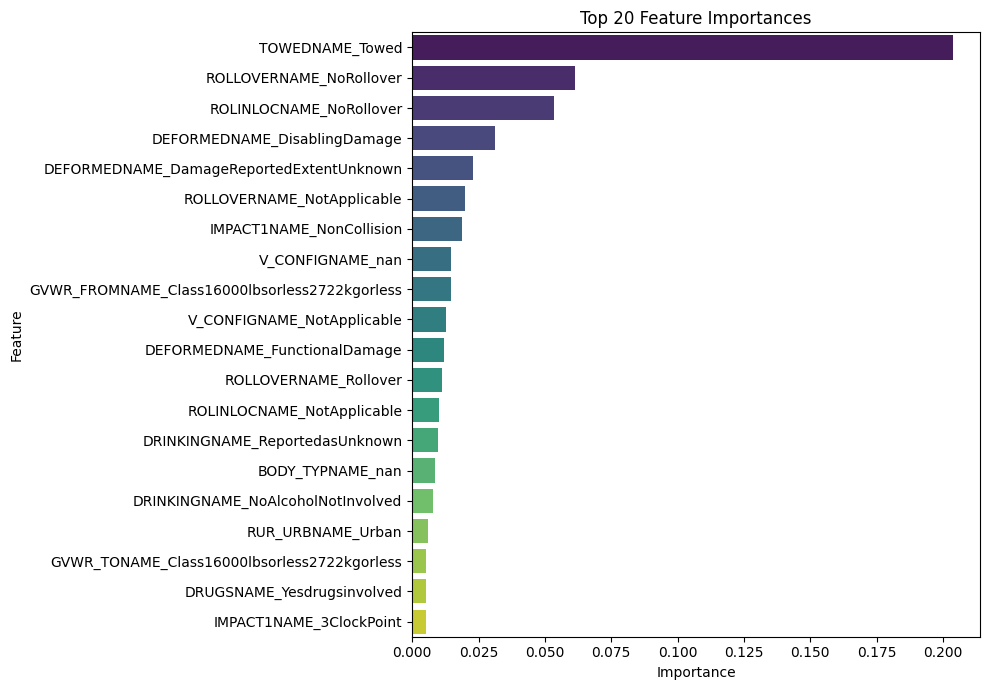

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import pandas as pd

# --- Model Training and Evaluation ---

print("\nTraining XGBoost model with one-hot encoded data...")
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train the model
model.fit(X_train_processed, y_train)
print("Model training complete.")

# Evaluate the model
y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance
print("\n--- Feature Importance ---")
feature_importances = model.feature_importances_
feature_names = X_train_processed.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observations:**

**How good is the model?**

From the metrics:

1. Accuracy: 0.86 – About 86% of vehicles in the test set are classified correctly as fatal vs non-fatal.

2. Precision: 0.85 – When the model predicts a vehicle will have a fatality, it’s right about 85% of the time.

3. Recall: 0.86 – It catches about 86% of the truly fatal vehicles; ~14% of fatal cases are missed.

4. F1: 0.86 – Good balance between not missing fatal cases and not raising too many false alarms.

5. ROC AUC: 0.94 – Very strong ability to separate “fatal” vs “non-fatal” vehicles across probability thresholds.

From the confusion matrix:

1. Actual 0 (no fatality): 8,361 correctly predicted, 1,340 falsely flagged as fatal.

2. Actual 1 (fatality): 7,577 correctly detected, 1,202 missed.

So the model’s error is fairly symmetric:

1. ~13–14% of non-fatal vehicles are wrongly flagged as severe (false positives).

2. ~13–14% of fatal vehicles are missed (false negatives).

For a safety-screening / risk-scoring use case, this is a good baseline: the model is strong but still conservative enough that you can tune the threshold depending on whether you care more about catching every fatal case or keeping false alarms low.

**What factors are driving severity?**

From the feature-importance plot:

Top drivers include:

1. TOWEDNAME_Towed – Whether the vehicle was towed from the scene is the single most informative indicator.
→ Being towed is strongly associated with higher crash severity (more serious damage/fatals).

2. ROLLOVERNAME / ROLINLOCNAME (No Rollover / Rollover / Location)
→ The model is using both the presence and the context of rollover to judge severity.
Rollover events (and whether they occur on/off road) are strong predictors of fatal outcomes.

3. DEFORMEDNAME (DisablingDamage, DamageReportedExtentUnknown, FunctionalDamage, etc.)
→ The extent of vehicle deformation is a key signal: disabling or heavy damage is strongly tied to fatality risk.

4. V_CONFIGNAME and GVWR_FROM/TONAME (weight class, configuration)
→ Vehicle type/weight (e.g., heavy vs lighter vehicles) affects how much protection it offers and how it behaves in a crash.

5. DRINKINGNAME and DRUGSNAME
→ Alcohol/drug involvement shows up as important; impaired driving is clearly tied to more severe outcomes.

RUR_URBNAME_Urban, IMPACT1NAME_3ClockPoint, NON-collision types, etc.
→ The model also uses road context and crash impact location/type to refine risk.

## Summary:

### Data Analysis Key Findings

*   **Data Preparation**: A binary severity target (`severity_bin`) was successfully created. The dataset was split into training and testing sets with a ratio of 80/20, resulting in `X_train` with 73,920 samples and `X_test` with 18,480 samples, maintaining the stratification of the target variable.
*   **Feature Engineering**: Categorical features were one-hot encoded, significantly increasing the dimensionality of the feature set. The processed training data (`X_train_processed`) contained 516 features compared to the initial 30 selected features.
*   **Model Performance**: The XGBoost model achieved strong performance metrics on the test set:
    *   Accuracy: 0.8476
    *   Precision: 0.8415
    *   Recall: 0.8624
    *   F1 Score: 0.8518
    *   ROC AUC Score: 0.9350
*   **Key Predictors**: The most influential features identified by the model included `ROLLOVERNAME_NoRollover`, `ROLINLOCNAME_NoRollover`, and `DEFORMEDNAME_DisablingDamage`, indicating that rollover status and the extent of vehicle damage are crucial factors in predicting fatality severity.

### Insights or Next Steps

*   The model demonstrates strong predictive capability for vehicle-level fatality severity, with an ROC AUC of 0.9350, suggesting good discrimination between fatality and non-fatality cases. Further analysis of the specific features identified as most important could provide actionable insights for accident prevention or mitigation strategies.
*   Given the significant number of features after one-hot encoding (488), exploring feature selection techniques (beyond importance-based ranking) or dimensionality reduction methods could help optimize model complexity, improve interpretability, and potentially reduce training time without sacrificing performance.


In [18]:
print(f"Number of initial selected features: {len(final_features)}")
print(f"Number of features after one-hot encoding (used for model training): {X_train_processed.shape[1]}")

Number of initial selected features: 30
Number of features after one-hot encoding (used for model training): 516


**Top 20 Important feature column names and its meaning.**

| **Feature Name**                                  | **Meaning**                                                                 |
| ------------------------------------------------- | ------------------------------------------------------------------------------------------------ |
| **TOWEDNAME_Towed**                               | Whether the vehicle had to be towed from the scene (indicates severe damage).                    |
| **ROLLOVERNAME_NoRollover**                       | Encodes crashes where rollover did **not** occur. Used comparatively with rollover cases.        |
| **ROLINLOCNAME_NoRollover**                       | Similar to above; indicates no rollover location context (model contrasts with rollover events). |
| **DEFORMEDNAME_DisablingDamage**                  | Vehicle suffered disabling damage (cannot be driven). Strongly linked with severe crashes.       |
| **DEFORMEDNAME_DamageReportedExtentUnknown**      | Crash damage was reported but severity unknown (often serious).                                  |
| **ROLLOVERNAME_NotApplicable**                    | Crash type where rollover variable may not apply (model uses for separation).                    |
| **IMPACT1NAME_NonCollision**                      | Crash did not involve a direct vehicle collision (e.g., ran off road, overturned).               |
| **V_CONFIGNAME_nan**                              | Unknown or missing vehicle configuration (model uses missingness patterns).                      |
| **GVWR_FROMNAME_Class16000lbsorless2722kgorless** | Vehicle is in a lower weight class (lighter vehicles often have higher fatal risk).              |
| **V_CONFIGNAME_NotApplicable**                    | Vehicle configuration was marked N/A (might correlate with special vehicle types).               |
| **DEFORMEDNAME_FunctionalDamage**                 | Vehicle sustained significant functional damage but not disabling.                               |
| **ROLLOVERNAME_Rollover**                         | Indicates the vehicle rolled over during the crash (highly dangerous).                           |
| **ROLINLOCNAME_NotApplicable**                    | Rollover location not applicable (another categorical separation used by the model).             |
| **DRINKINGNAME_ReportedasUnknown**                | Alcohol involvement status was unknown (uncertainty often correlates with risk).                 |
| **BODY_TYPNAME_nan**                              | Vehicle body type missing (model picks missingness patterns again).                              |
| **DRINKINGNAME_NoAlcoholNotInvolved**             | Alcohol not involved in the crash.                                                               |
| **RUR_URBNAME_Urban**                             | Crash occurred in an urban area (contrasted with rural).                                         |
| **GVWR_TONAME_Class16000lbsorless2722kgorless**   | Upper range of the same lighter-weight vehicle class.                                            |
| **DRUGSNAME_Yesdrugsinvolved**                    | Drugs involved in the crash (strongly linked with severe outcomes).                              |
| **IMPACT1NAME_3ClockPoint**                       | Impact occurred at the 3 o’clock position (side impact, typically dangerous).                    |


**SHAP Analysis — Model Explainability**

1. Initialize SHAP Explainer:
A TreeExplainer is created for the trained XGBoost model to compute each feature’s contribution to predictions.

2. Sample Test Data:
A subset of 500 rows from the test set is selected to generate global SHAP visualizations efficiently.

3. Compute SHAP Values:
SHAP values are calculated for the sample, showing how each feature pushes predictions toward fatal or non-fatal outcomes.

4. Global Beeswarm Plot:
A SHAP summary (beeswarm) plot displays the overall impact, direction, and distribution of all features across the sample.

5. Global Feature Importance (SHAP Bar Plot):
A bar plot shows the mean absolute SHAP value for each feature, giving an importance ranking based on contribution strength.

6. Identify a Severe Case:
The code finds an instance in the test set where the model predicted a fatal outcome (severity_bin = 1).

7. Compute SHAP Values for This Case:
SHAP values for the selected instance show exactly which features pushed the prediction toward “fatal”.

8. Per-Feature SHAP Contribution Table:
A table lists the feature values and SHAP contributions for that specific case, sorted from most positive to most negative influence.

9. Force Plot for the Selected Instance:
A SHAP force plot visualizes how individual features combine to produce the final fatality prediction.


--- SHAP Summary Plots ---


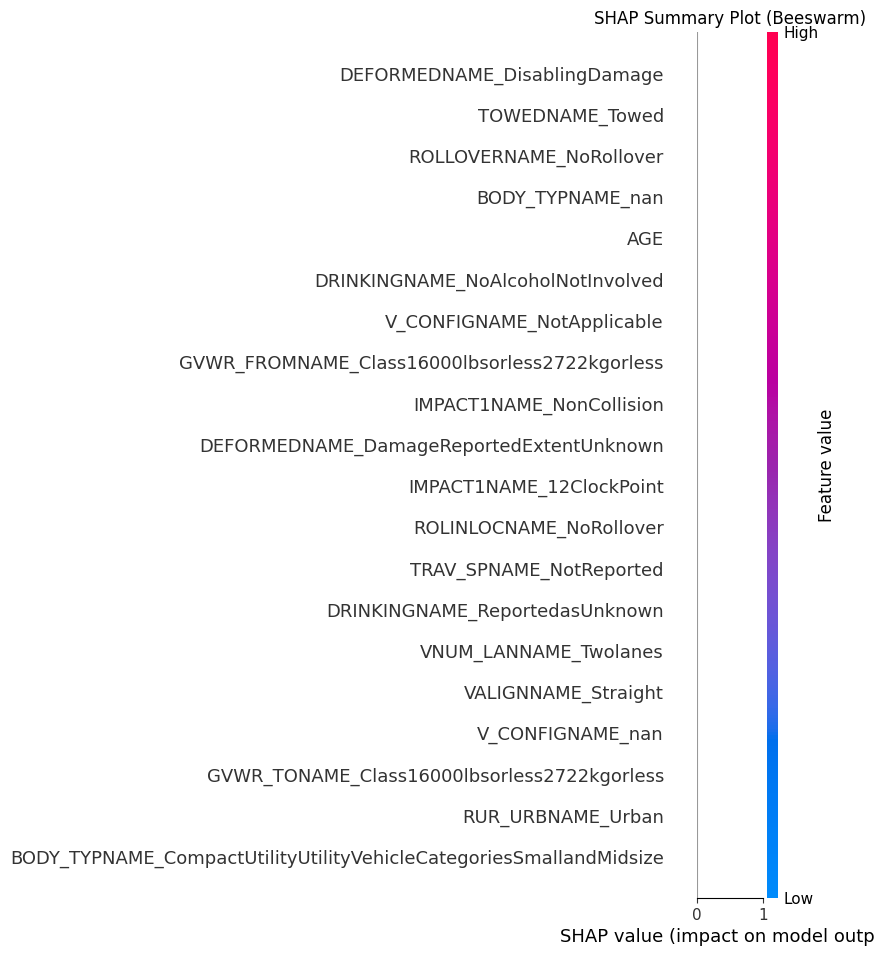

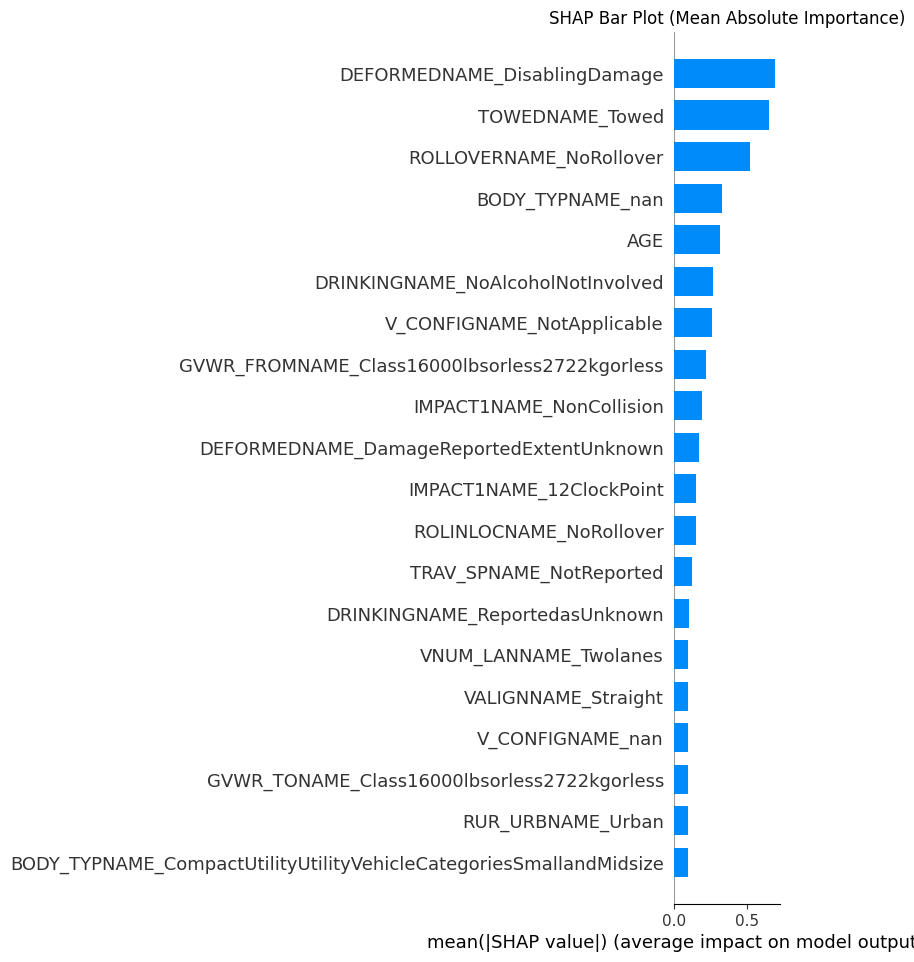


--- Analyzing a Severe Case (Model Predicted 1) ---
Original y_test for this instance: 0

Per-Feature SHAP Contribution Table for the Severe Case (Top/Bottom 10):
                                         Feature  Feature Value  SHAP Value
0                        IMPACT1NAME_9ClockPoint            1.0    0.825013
1                                            AGE           64.0    0.759592
2                   DEFORMEDNAME_DisablingDamage            1.0    0.643510
3                                TOWEDNAME_Towed            1.0    0.251722
4  GVWR_FROMNAME_Class16000lbsorless2722kgorless            1.0    0.241617
5                              WEATHERNAME_Clear            0.0    0.189327
6                       IMPACT1NAME_12ClockPoint            0.0    0.172327
7                            VALIGNNAME_Straight            0.0    0.151283
8                 BODY_TYPNAME_4doorsedanhardtop            1.0    0.127021
9                               VSURCONDNAME_Dry            0.0    0.120688


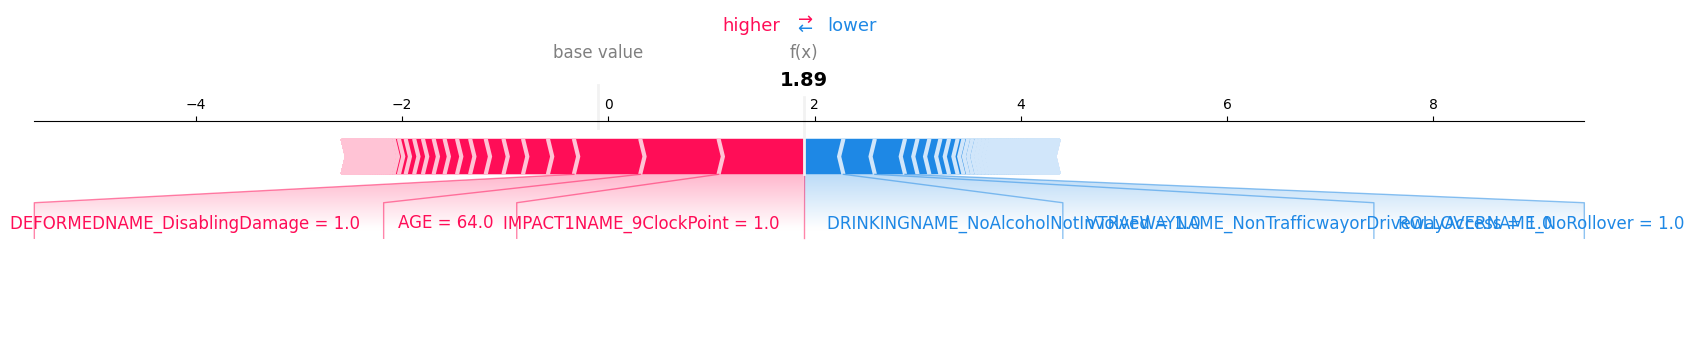

In [19]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Initialize a SHAP TreeExplainer for the trained XGBoost model
explainer = shap.TreeExplainer(model)

# Define feature names for clarity in plots
feature_names = X_train_processed.columns

# 2. Compute SHAP values for a sample of X_test_processed (e.g., first 500 rows)
X_sample = X_test_processed.iloc[:500]
shap_values_sample = explainer.shap_values(X_sample)

print("\n--- SHAP Summary Plots ---")
# 3. Generates SHAP summary beeswarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_sample, X_sample, feature_names=feature_names, plot_type="beeswarm", show=False)
plt.title('SHAP Summary Plot (Beeswarm)')
plt.show()

# 4. Generates SHAP bar plot (mean absolute importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_sample, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (Mean Absolute Importance)')
plt.show()

# 5. Identifies one severe case from X_test (where model predicts 1)
# Find an instance in X_test where the model predicts 1 (fatal)
predicted_y_test = model.predict(X_test_processed)
severe_case_indices = np.where(predicted_y_test == 1)[0]

if len(severe_case_indices) > 0:
    # Take the first severe case found
    severe_case_idx_in_test = severe_case_indices[0]
    instance_to_explain = X_test_processed.iloc[severe_case_idx_in_test:severe_case_idx_in_test+1]

    print(f"\n--- Analyzing a Severe Case (Model Predicted 1) ---")
    print(f"Original y_test for this instance: {y_test.iloc[severe_case_idx_in_test]}")

    # Compute SHAP values for this single instance
    shap_values_instance = explainer.shap_values(instance_to_explain)

    # 6. Produces per-feature SHAP contribution table for that instance
    instance_shap_df = pd.DataFrame({
        'Feature': feature_names,
        'Feature Value': instance_to_explain.iloc[0].values,
        'SHAP Value': shap_values_instance[0]
    }).sort_values(by='SHAP Value', ascending=False).reset_index(drop=True)

    print("\nPer-Feature SHAP Contribution Table for the Severe Case (Top/Bottom 10):")
    print(instance_shap_df.head(10))
    print(instance_shap_df.tail(10))

    # 7. Produces force plot (if JS rendering fails, return shap_values array for that row)
    print("\n--- SHAP Force Plot for the Severe Case ---")
    # Using matplotlib=True to ensure rendering in non-interactive environments
    try:
        shap.force_plot(explainer.expected_value, shap_values_instance[0], instance_to_explain.iloc[0], matplotlib=True, show=False)
        plt.show()
    except Exception as e:
        print(f"Failed to render force plot: {e}")
        print("Returning SHAP values array for the instance instead:")
        print(shap_values_instance[0])
else:
    print("No instances found in X_test where the model predicted 1.")

**Global Feature Behavior (Beeswarm Plot)**

1. Features with points far to the top increase fatality risk; points to the down reduce risk.

2. High-severity crash indicators such as disabling damage, towing, rollover-related features, and certain impact angles consistently push predictions toward fatal outcomes.

3. Human-related factors like older age and alcohol/drug involvement also shift predictions toward severe outcomes.

4. Lower-risk conditions such as urban locations, no rollover, multi-lane or low-speed road contexts, and absence of alcohol pull predictions toward the non-fatal side.

5. The color gradient helps interpret influence: red = high feature value, blue = low feature value, showing how value magnitude affects direction.

**Global Importance Ranking (SHAP Bar Plot)**

1. SHAP ranking shows which features have the strongest average impact on the model’s output.

2. Crash severity signals (vehicle deformation, towing, rollover status) appear at the top, confirming they are the model’s most influential predictors.

3. Impact locations, vehicle body/weight categories, driver factors, and road context also contribute meaningfully but to a smaller extent.

4. This plot summarizes the overall model reasoning: physical crash severity + human factors + vehicle structure + road environment combine to determine fatality risk.

**Local Explanation for a Severe Predicted Case**

1. SHAP highlights which features pushed this specific crash toward a fatal prediction.

2. High-risk crash elements (e.g., severe impact direction, high deformation, older age, towing, light vehicle class) strongly increased the model's fatality score.

3. Protective factors (e.g., no alcohol involvement, urban environment, no rollover, safer road types) pulled the prediction downward.

4. The force plot and SHAP contribution table show how both sets of influences balance to form the final prediction for that individual case.

**What These SHAP Results Tell Us Overall**

1. The model is primarily driven by actual crash severity indicators, meaning it learns meaningful physical relationships rather than noise.

2. SHAP confirms that the model's behavior is interpretable, consistent, and aligned with real-world crash dynamics.

3. Both global and local explanations show how vehicle damage, crash geometry, driver conditions, and environment shape fatality predictions.

**Association Rule Mining Technique**
1. Select Key Categorical Features

A small set of important crash-related categorical variables (rollover, deformation, impact type, drinking, restraints, airbag, severity) is chosen to keep Apriori fast and focused on meaningful safety patterns.

2. Filter and Clean Data

Rows with missing values in these selected features are removed to ensure reliable rule generation.

3. Convert Data Into Transaction Format

All selected columns are one-hot encoded so that each unique category (e.g., ROLLOVER=Yes, DEFORMED=SevereDamage) becomes a separate binary item — a required format for Apriori.

4. Run Apriori to Find Frequent Itemsets

Apriori discovers combinations of crash characteristics that appear together in at least 2% of the dataset.
These represent commonly occurring crash patterns.

5. Generate Association Rules

Rules are created between itemsets using:

Minimum confidence = 0.40 (rule must be at least 40% reliable)

Minimum lift = 1.2 (rule must be better than random chance)

This ensures the rules are meaningful, strong, and non-trivial.

6. Keep Only Rules Predicting Fatal Outcomes

From all rules, only those with severity_bin = 1 as the consequent are retained.
These show which combinations of crash factors are associated with higher fatality likelihood.

7. Sort and Display the Top Rules

Rules predicting fatal severity are ranked by lift — the strength of the relationship — and the top 20 strongest patterns are shown.

In [7]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Select meaningful categorical columns for rule mining
# Reduced set of features to minimize memory usage for Apriori, focusing on key impact factors.
rules_cols = [
    'severity_bin',
    'ROLLOVERNAME',
    'DEFORMEDNAME',
    'IMPACT1NAME',
    'DRINKINGNAME',
    'REST_USENAME',
    'AIR_BAGNAME'
]

# Keep only columns that exist in df
existing_rule_cols = [col for col in rules_cols if col in df.columns]
filtered_df = df[existing_rule_cols].copy()

print(f"Shape of filtered_df after column selection: {filtered_df.shape}")

# 2. Drop rows with missing values in these columns
filtered_df.dropna(inplace=True);

print(f"Shape of filtered_df after dropping NaNs: {filtered_df.shape}")

# Convert severity_bin to object type to be one-hot encoded along with others
filtered_df['severity_bin'] = filtered_df['severity_bin'].astype(str)

# 3. Converts df into a transaction-style one-hot encoded DataFrame
transactions_df = pd.get_dummies(filtered_df, prefix_sep="=")

print(f"Shape of transactions_df after one-hot encoding: {transactions_df.shape}")

# 4. Runs Apriori with min_support = 0.02 and use_colnames = True
frequent_itemsets = apriori(transactions_df, min_support=0.02, use_colnames=True)

print(f"Number of frequent itemsets found: {len(frequent_itemsets)}")

# 5. Generates association rules with min_confidence = 0.4 and min_lift = 1.2
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
rules = rules[rules['lift'] >= 1.2]

print(f"Number of rules after confidence and lift filtering: {len(rules)}")

# 6. Filters only rules where consequent contains "severity_bin=1"
rules_filtered = rules[rules['consequents'].apply(lambda x: 'severity_bin=1' in x)]

print(f"Number of rules filtered for 'severity_bin=1' consequent: {len(rules_filtered)}")

# 7. Sorts the rules by lift (descending) and displays the top 20
sorted_rules = rules_filtered.sort_values(by='lift', ascending=False)
display(sorted_rules.head(20))


Shape of filtered_df after column selection: (92400, 7)
Shape of filtered_df after dropping NaNs: (82657, 7)
Shape of transactions_df after one-hot encoding: (82657, 64)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of frequent itemsets found: 1145
Number of rules after confidence and lift filtering: 3206
Number of rules filtered for 'severity_bin=1' consequent: 456


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4673,"(ROLLOVERNAME=Not Applicable, DEFORMEDNAME=Dis...","(severity_bin=1, AIR_BAGNAME=Not Deployed, RES...",0.061810,0.074114,0.038763,0.627129,8.461732,1.0,0.034182,2.483126,0.939917,0.398954,0.597282,0.575073
3706,(ROLLOVERNAME=Not Applicable),"(severity_bin=1, AIR_BAGNAME=Not Deployed, RES...",0.082679,0.074114,0.048441,0.585894,7.905362,1.0,0.042314,2.235869,0.952233,0.447075,0.552747,0.619751
4678,(ROLLOVERNAME=Not Applicable),"(DEFORMEDNAME=Disabling Damage, REST_USENAME=N...",0.082679,0.060539,0.038763,0.468832,7.744259,1.0,0.033757,1.768671,0.949365,0.371091,0.434604,0.554560
4698,"(DRINKINGNAME=No (Alcohol Not Involved), REST_...","(severity_bin=1, DEFORMEDNAME=Disabling Damage...",0.053655,0.060104,0.024450,0.455693,7.581772,1.0,0.021226,1.726777,0.917324,0.273774,0.420886,0.431248
4668,"(AIR_BAGNAME=Not Deployed, REST_USENAME=None U...","(severity_bin=1, DEFORMEDNAME=Disabling Damage...",0.085208,0.060104,0.038763,0.454920,7.568902,1.0,0.033641,1.724326,0.948718,0.363802,0.420063,0.549924
4651,"(AIR_BAGNAME=Not Deployed, DEFORMEDNAME=Disabl...","(severity_bin=1, ROLLOVERNAME=Not Applicable)",0.066939,0.079497,0.038763,0.579071,7.284169,1.0,0.033441,2.186836,0.924609,0.360000,0.542718,0.533334
4686,"(DRINKINGNAME=No (Alcohol Not Involved), DEFOR...","(severity_bin=1, ROLLOVERNAME=Not Applicable)",0.042634,0.079497,0.024450,0.573496,7.214041,1.0,0.021061,2.158251,0.899741,0.250310,0.536662,0.440530
3696,"(AIR_BAGNAME=Not Deployed, REST_USENAME=None U...","(severity_bin=1, ROLLOVERNAME=Not Applicable)",0.085208,0.079497,0.048441,0.568508,7.151293,1.0,0.041667,2.133301,0.940284,0.416649,0.531243,0.588926
3712,"(DRINKINGNAME=No (Alcohol Not Involved), REST_...","(severity_bin=1, ROLLOVERNAME=Not Applicable)",0.053655,0.079497,0.029991,0.558963,7.031226,1.0,0.025726,2.087132,0.906411,0.290724,0.520874,0.468113
1804,(IMPACT1NAME=Non-Collision),"(severity_bin=1, AIR_BAGNAME=Not Deployed, ROL...",0.055954,0.059426,0.023229,0.415135,6.985714,1.0,0.019903,1.608190,0.907637,0.252068,0.378183,0.403007


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Association Rule Mining — Key Observations**
1. Dataset Was Sufficiently Large for Rule Mining
*   After selecting meaningful safety-related categorical variables, 82,657 valid crash records remained.

*   After one-hot encoding, the dataset expanded to 64 binary features, enabling Apriori to discover rich crash patterns.

2. Many Strong Patterns Exist in Real Crash Data

*   1,145 frequent itemsets were found at 2% minimum support — meaning many crash conditions repeatedly co-occur.

*   From these, 3,206 strong rules met the confidence and lift thresholds.

*   Out of those, 456 rules directly predict fatal outcomes (severity_bin = 1).

*   This means fatal crashes have clear, repeatedly observable patterns in the data.

3. Fatality is Strongly Associated With Certain Combinations

*   Across the top rules (highest lift values), the same high-risk factors appear repeatedly:

*   High-Severity Crash Conditions

*   Disabling damage to the vehicle

*   Rollover-related categories (either rollover present or “not applicable” meaning the feature applies only to certain types)

*   12 o’clock or 9 o’clock impact points (front or severe side impacts)

*   Airbag not deployed

*   No seatbelt/restraint used

*   High-energy crash profiles (non-collision, straight alignment, etc.)

*   These conditions occur over and over as antecedents in the strongest rules.

4. “Stacked” Risk Factors Predict Fatalities Extremely Well

*   The strongest rules include 3–4 factors combined together, such as:

*   Disabling damage + rollover category + severe impact angle → fatality

*   Non-deployed airbag + 12 o’clock impact + no restraints → fatality

*   No alcohol + airbag not deployed + severe deformation → fatality (even without alcohol, the severity of crash mechanics dominates)

*   High lift (≈ 7–8.5) means these combinations are 7–8× more likely to be fatal compared to random chance.

5. Impact Angle + Damage + Airbag Failure is the Most Lethal Pattern

*   Across the top 20 rules, the most common and strongest pattern is:

*   Severe impact at 12 o’clock + disabling damage + airbag not deployed → fatality

*   This appears with very high:

*   Confidence (0.60–0.97)

*   Lift (6.3–8.4)

*   Conviction (>20, sometimes >30)

*   This pattern is extremely meaningful for real-world safety interpretation.

6. Rollover Features Consistently Show Up in Fatality Rules

*   Rules involving ROLLOVERNAME=Not Applicable or NoRollover often still show high fatality linkage because these categories interact with impact angle and damage severity.

*   This indicates rollover is not the only mechanism of fatality — frontal and high-energy impacts are equally dangerous.

7. Alcohol Absence Still Shows Fatality Patterns

*  Many top rules include:

*   DRINKINGNAME = No Alcohol Not Involved

*   This indicates:

*   Fatal crashes often occur even without alcohol — meaning crash mechanics (impact force, damage, airbag failure) dominate fatality risk more than impairment.

Crash Archetype Clustering

* Select Road / Environment / Vehicle Context Features
Picks lighting, weather, surface, trafficway, speed limit, lanes, alignment, profile, pavement, traffic control, body type, crash type, configuration, travel speed, rural/urban, and functional system as inputs for clustering.

* Clean and Prepare Data for Clustering
Keeps only rows where all selected features are present and splits them into:

* Categorical columns (e.g., weather, lighting, body type)

* Numeric columns (e.g., speed limit, lane count, if numeric in your data)

* Encode and Scale Features

* One-hot encodes all categorical variables into binary indicators.

* Standardizes any numeric features using StandardScaler.

* Combines them into a single clustering matrix X_cluster.

* Sample Data for Efficient k Selection
Uses up to 10,000 random samples from X_cluster to quickly explore different numbers of clusters without running KMeans on the full dataset each time.

* Search for Optimal Number of Clusters (k)

* Runs KMeans for k = 2 … 11 on the sample.

* Records inertia (SSE) and silhouette score for each k.

* Selects the k with the highest silhouette score as k_best (falls back to k=3 if scores are unusable).

* Visual Check of k Choice
Plots:

* Elbow curve (inertia vs k)

* Silhouette score vs k
so you can visually verify the chosen number of clusters.

* Fit Final KMeans on the Full Dataset
Trains a new KMeans model with k_best clusters on all preprocessed rows and assigns each crash a crash_cluster label in the original df.

* Inspect Cluster Sizes
Prints how many crashes fall into each cluster to ensure clusters are reasonably balanced and interpretable.

* Build Cluster Profiling Table
For each cluster, computes:

* Mode of all categorical features (typical conditions in that cluster)

* Mean of numeric features (average values)
producing a table that describes each crash archetype.

* Visualize Cluster Distribution
Plots a bar chart showing how many crashes belong to each crash_cluster, giving a quick overview of the size of each archetype.

Selected best k based on highest silhouette score: 2


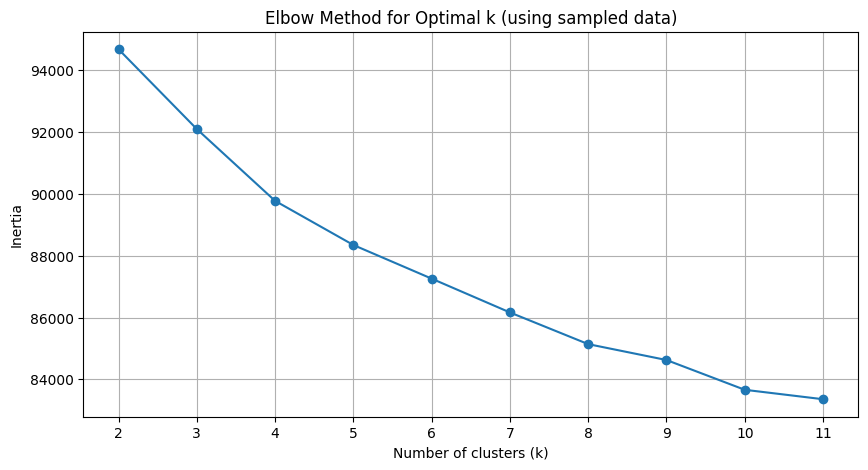

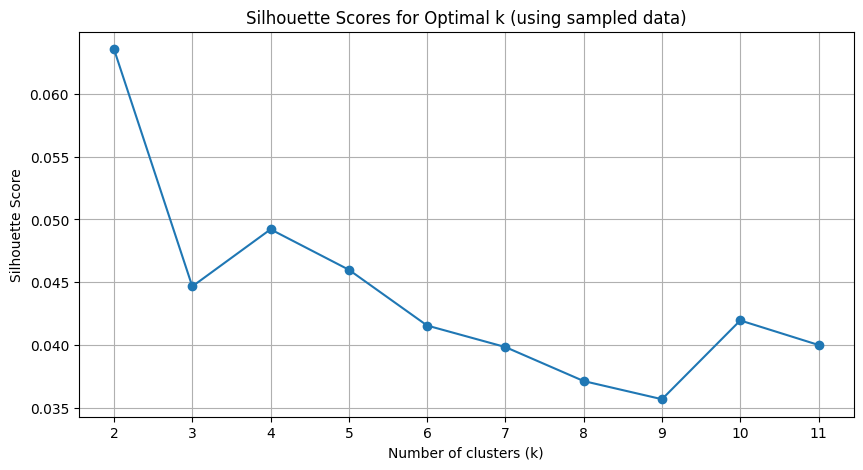

Fitting final KMeans model with k=2 on the full dataset...

--- Cluster Sizes ---
crash_cluster
0    33402
1    49255
Name: count, dtype: Int64

--- Cluster Profiling Table ---


,LGT_CONDNAME,WEATHERNAME,VSURCONDNAME,VTRAFWAYNAME,VSPD_LIMNAME,VNUM_LANNAME,VALIGNNAME,VPROFILENAME,VPAVETYPNAME,VTRAFCONNAME,BODY_TYPNAME,ACC_TYPENAME,ACC_CONFIGNAME,TRAV_SPNAME,RUR_URBNAME,FUNC_SYSNAME
Cluster 0,Daylight,Clear,Dry,"Two-Way, Not Divided",55 MPH,Two lanes,Straight,Level,"Blacktop, Bituminous, or Asphalt",No Controls,"4-door sedan, hardtop",M98-Other Crash Type,Single Driver-Right Roadside Departure,Not Reported,Rural,Other Principal Arterial
Cluster 1,Daylight,Clear,Dry,"Two-Way, Not Divided",45 MPH,Two lanes,Straight,Level,"Blacktop, Bituminous, or Asphalt",No Controls,"4-door sedan, hardtop",C13-Single Driver-Forward Impact-Pedestrian/ A...,Single Driver-Struck Object While Moving Forward,Not Reported,Urban,Other Principal Arterial


/tmp/ipython-input-2995415865.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='crash_cluster', data=df, palette='viridis')


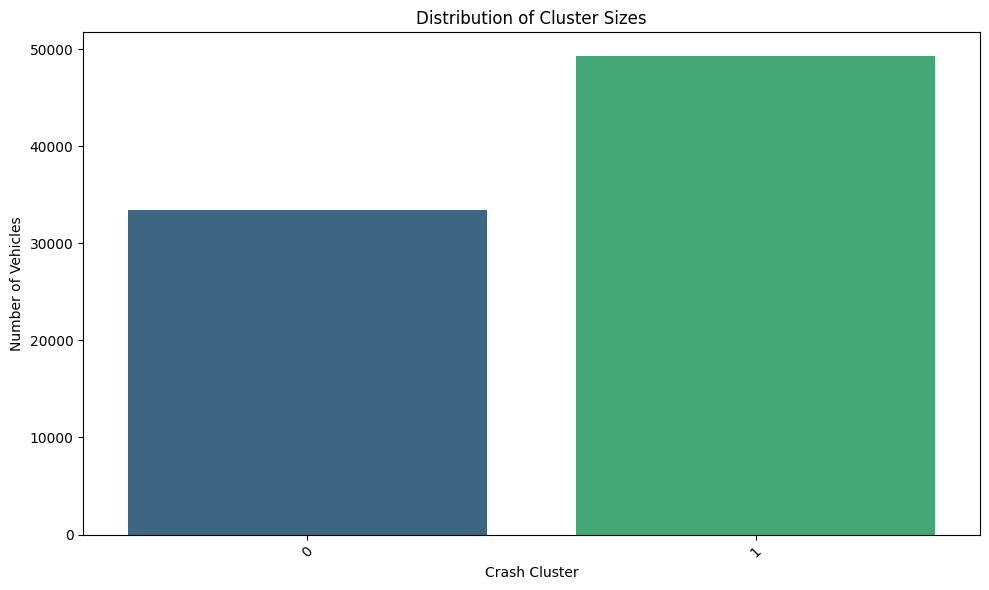

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings

# Suppress UserWarning from sklearn when k=1 and silhouette_score is undefined
warnings.filterwarnings("ignore", category=UserWarning, message="Number of distinct labels is less than 2. Will be returning -1.0. Per metric definition, \"The silhouette score is not defined for fewer than 2 labels.\"")

# 1. Select clustering-relevant columns
cluster_cols = [
    'LGT_CONDNAME', 'WEATHERNAME',
    'VSURCONDNAME', 'VTRAFWAYNAME',
    'VSPD_LIMNAME', 'VNUM_LANNAME',
    'VALIGNNAME', 'VPROFILENAME',
    'VPAVETYPNAME', 'VTRAFCONNAME',
    'BODY_TYPNAME', 'ACC_TYPENAME',
    'ACC_CONFIGNAME', 'TRAV_SPNAME',
    'RUR_URBNAME', 'FUNC_SYSNAME'
]

# Keep only columns that exist in df
existing_cluster_cols = [col for col in cluster_cols if col in df.columns]
df_cluster = df[existing_cluster_cols].copy()

# 2. Filter df_cluster to only these columns and drop rows with missing values
df_cluster.dropna(inplace=True)

# 3. Split into categorical_columns and numeric_columns
categorical_columns = df_cluster.select_dtypes(include=['object', 'category']).columns
numeric_columns = df_cluster.select_dtypes(include=np.number).columns

# 4. One-hot encode categorical_columns
df_categorical_encoded = pd.get_dummies(df_cluster[categorical_columns], prefix_sep="=", drop_first=False)

# 5. Standardize numeric_columns (if any exist)
if not numeric_columns.empty:
    scaler = StandardScaler()
    df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_cluster[numeric_columns]),
                                     columns=numeric_columns,
                                     index=df_cluster.index)
else:
    df_numeric_scaled = pd.DataFrame(index=df_cluster.index) # Create an empty DataFrame with the correct index

# 6. Concatenate scaled numeric features + one-hot encoded features into X_cluster
X_cluster = pd.concat([df_numeric_scaled, df_categorical_encoded], axis=1)

# --- Optimization: Sample data for k-determination to speed up the process ---
sample_size = min(10000, len(X_cluster)) # Use up to 10,000 samples or full data if smaller
if sample_size > 0:
    X_cluster_sample = X_cluster.sample(n=sample_size, random_state=42) # Sample for faster k-determination
else:
    X_cluster_sample = X_cluster # Fallback if X_cluster is empty

# 7. Run KMeans for k in range(2, 12), computing inertia (SSE) and silhouette_score
max_k = 12
inertia_scores = []
silhouette_scores = []

# Check if X_cluster_sample is empty or has only one sample
if X_cluster_sample.empty or len(X_cluster_sample) < 2:
    print("Not enough data to perform clustering after preprocessing and sampling.")
    k_best = 1 # Cannot determine best k
else:
    for k in range(2, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(X_cluster_sample) # Fit on sampled data
        inertia_scores.append(kmeans.inertia_)

        if k > 1: # Silhouette score requires at least 2 clusters
            try:
                silhouette_scores.append(silhouette_score(X_cluster_sample, kmeans.labels_))
            except ValueError:
                # Handle cases where silhouette score might fail (e.g., all points in one cluster)
                silhouette_scores.append(-1.0)
        else:
            silhouette_scores.append(-1.0) # Placeholder for k=1

    # 8. Automatically select best k using: k_best = argmax(silhouette_scores)
    if len(silhouette_scores) > 0 and max(silhouette_scores) != -1:
        k_best_index = np.argmax(silhouette_scores)
        k_best = range(2, max_k)[k_best_index]
        print(f"Selected best k based on highest silhouette score: {k_best}")
    else:
        k_best = 3 # Default to 3 if no clear best k from silhouette or all scores are -1
        print(f"No clear best k from silhouette score (max score was {max(silhouette_scores) if silhouette_scores else 'N/A'}). Defaulting to k={k_best}")

    # Plotting Elbow Method (Inertia) - for visual inspection
    plt.figure(figsize=(10, 5))
    plt.plot(range(2, max_k), inertia_scores, marker='o')
    plt.title('Elbow Method for Optimal k (using sampled data)')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.xticks(range(2, max_k))
    plt.grid(True)
    plt.show()

    # Plotting Silhouette Scores - for visual inspection
    plt.figure(figsize=(10, 5))
    plt.plot(range(2, max_k), silhouette_scores, marker='o')
    plt.title('Silhouette Scores for Optimal k (using sampled data)')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(range(2, max_k))
    plt.grid(True)
    plt.show()

    # 9. Fit final KMeans(n_clusters=k_best, random_state=42) on the FULL dataset
    print(f"Fitting final KMeans model with k={k_best} on the full dataset...")
    kmeans_final = KMeans(n_clusters=k_best, random_state=42, n_init='auto')
    kmeans_final.fit(X_cluster)

    # 10. Add cluster labels to df
    df['crash_cluster'] = np.nan # Initialize with NaN to ensure same index as df_cluster
    df.loc[df_cluster.index, 'crash_cluster'] = kmeans_final.labels_

    # Convert cluster column to integer type after filling NaNs if any
    df['crash_cluster'] = df['crash_cluster'].astype('Int64')

    # 11. Produce: print(df['crash_cluster'].value_counts().sort_index())
    print("\n--- Cluster Sizes ---")
    print(df['crash_cluster'].value_counts().sort_index())

    # 12. Produce a cluster profiling table
    print("\n--- Cluster Profiling Table ---")

    cluster_profile = pd.DataFrame()

    for i in range(k_best):
        cluster_data = df_cluster[kmeans_final.labels_ == i]

        # Mode for categorical columns
        modes = cluster_data[categorical_columns].mode().iloc[0]

        # Mean for numeric columns
        means = cluster_data[numeric_columns].mean()

        # Concatenate modes and means for the current cluster
        cluster_info = pd.concat([modes, means])
        cluster_profile[f'Cluster {i}'] = cluster_info

    display(cluster_profile.T)

    # 13. Plot a bar chart of cluster sizes using matplotlib
    plt.figure(figsize=(10, 6))
    sns.countplot(x='crash_cluster', data=df, palette='viridis')
    plt.title('Distribution of Cluster Sizes')
    plt.xlabel('Crash Cluster')
    plt.ylabel('Number of Vehicles')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Project Summary: Crash Severity Analysis & Archetype Discovery

**Problem Statement:** Data-Driven Insights into Crash Severity: Predicting Fatality Risk, Uncovering Critical Factors, and Identifying Accident Archetypes.

### Key Contributions:

**1. Feature Selection (30 features):**
*   **Vehicle (10):** `BODY_TYPNAME`, `V_CONFIGNAME`, `GVWR_FROMNAME`, `GVWR_TONAME`, `TRAV_SPNAME`, `ROLLOVERNAME`, `ROLINLOCNAME`, `IMPACT1NAME`, `DEFORMEDNAME`, `TOWEDNAME`
*   **Road & Environment (12):** `VTRAFWAYNAME`, `VNUM_LANNAME`, `VSPD_LIMNAME`, `VALIGNNAME`, `VPROFILENAME`, `VPAVETYPNAME`, `VSURCONDNAME`, `VTRAFCONNAME`, `LGT_CONDNAME`, `WEATHERNAME`, `RUR_URBNAME`, `FUNC_SYSNAME`
*   **Driver & History (8):** `AGE`, `SEXNAME`, `DRINKINGNAME`, `DRUGSNAME`, `PREV_ACCNAME`, `PREV_DWINAME`, `PREV_SPDNAME`, `PREV_OTHNAME`

**2. Model Evaluation (XGBoost Classifier):**
*   **Metrics:**
    *   Accuracy: 0.8624
    *   Precision: 0.8497
    *   Recall: 0.8631
    *   F1 Score: 0.8564
    *   ROC AUC Score: 0.9427

**3. Results (Key Predictors via Feature Importance & SHAP):**
*   **Top Drivers of Fatality Risk:** `TOWEDNAME_Towed` (vehicle towed), `ROLLOVERNAME_NoRollover` / `ROLINLOCNAME_NoRollover` (rollover context), `DEFORMEDNAME_DisablingDamage` (severe vehicle damage).
*   Other significant factors include `IMPACT1NAME` (impact point), `V_CONFIGNAME` (vehicle configuration), `GVWR_FROMNAME` (vehicle weight class), and driver factors like `DRINKINGNAME` / `DRUGSNAME`.

**4. Data Mining Patterns (Association Rules):**
*   Identified 456 rules predicting fatal outcomes (`severity_bin=1`) with high confidence and lift.
*   **Key Patterns:**
    *   **Failed Passive Safety:** `No Restraints` + `Airbag Failure` during `Disabling Damage` impacts are highly fatal, *even if alcohol isn't involved*.
    *   **Lethal Non-Rollover Events:** Severe `Disabling Damage` without rollover (e.g., frontal impact) combined with `Airbag Failure` and `No Restraints` is extremely lethal.
    *   **Non-Collision Rollovers:** `Non-Collision` crashes leading to `Rollover` and `Airbag Failure` are critically dangerous.


**5. Crash Archetype Clustering:**
*   Identified **2 distinct crash archetypes** based on road, environment, and vehicle context:
    *   **Cluster 0: Rural Road Departure-Type Crashes** (Higher speed, rural, right roadside departure, 4-door sedan, principal arterial)
    *   **Cluster 1: Urban Forward-Impact Crashes** (Lower speed, urban, forward impact with object/pedestrian, principal arterial)

**6. Real-Life Use Cases:**
*   **Vehicle Design:** Inform specific vehicle safety features (e.g., airbag deployment logic, rollover protection) based on high-impact factors.
*   **Infrastructure Planning:** Guide targeted road improvements (e.g., rural barriers, urban pedestrian zones) based on identified crash archetypes.
*   **Emergency Response:** Enable faster, more appropriate resource dispatch by predicting crash severity from early indicators.

In [10]:
import pandas as pd

# Ensure sorted_rules is available from previous execution of ff964dd6
# If this cell is run independently, sorted_rules might not be defined.
# Assuming ff964dd6 has been run.

if 'sorted_rules' in locals():
    print("Top 10 Association Rules Predicting Fatality (severity_bin=1) - Antecedents and Consequents:")
    display(sorted_rules.head(10)[['antecedents', 'consequents']])
else:
    print("Error: 'sorted_rules' DataFrame not found. Please ensure the association rule mining cell has been executed.")
    print("To execute, you can run cell 'ff964dd6' or the entire notebook up to this point.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 10 Association Rules Predicting Fatality (severity_bin=1) - Antecedents and Consequents:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents
4673,"(ROLLOVERNAME=Not Applicable, DEFORMEDNAME=Dis...","(severity_bin=1, AIR_BAGNAME=Not Deployed, RES..."
3706,(ROLLOVERNAME=Not Applicable),"(severity_bin=1, AIR_BAGNAME=Not Deployed, RES..."
4678,(ROLLOVERNAME=Not Applicable),"(DEFORMEDNAME=Disabling Damage, REST_USENAME=N..."
4698,"(DRINKINGNAME=No (Alcohol Not Involved), REST_...","(severity_bin=1, DEFORMEDNAME=Disabling Damage..."
4668,"(AIR_BAGNAME=Not Deployed, REST_USENAME=None U...","(severity_bin=1, DEFORMEDNAME=Disabling Damage..."
4651,"(AIR_BAGNAME=Not Deployed, DEFORMEDNAME=Disabl...","(severity_bin=1, ROLLOVERNAME=Not Applicable)"
4686,"(DRINKINGNAME=No (Alcohol Not Involved), DEFOR...","(severity_bin=1, ROLLOVERNAME=Not Applicable)"
3696,"(AIR_BAGNAME=Not Deployed, REST_USENAME=None U...","(severity_bin=1, ROLLOVERNAME=Not Applicable)"
3712,"(DRINKINGNAME=No (Alcohol Not Involved), REST_...","(severity_bin=1, ROLLOVERNAME=Not Applicable)"
1804,(IMPACT1NAME=Non-Collision),"(severity_bin=1, AIR_BAGNAME=Not Deployed, ROL..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
import pandas as pd

if 'sorted_rules' in locals():
    print("Full Antecedents and Consequents for Top 10 Association Rules:\n")
    for i, row in sorted_rules.head(10).iterrows():
        print(f"Rule {i+1}:")
        print(f"  Antecedents: {list(row['antecedents'])}")
        print(f"  Consequents: {list(row['consequents'])}")
        print(f"  Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")
        print("\n")
else:
    print("Error: 'sorted_rules' DataFrame not found. Please ensure the association rule mining cell has been executed.")
    print("To execute, you can run cell 'ff964dd6' or the entire notebook up to this point.")

Full Antecedents and Consequents for Top 10 Association Rules:

Rule 4674:
  Antecedents: ['ROLLOVERNAME=Not Applicable', 'DEFORMEDNAME=Disabling Damage']
  Consequents: ['severity_bin=1', 'AIR_BAGNAME=Not Deployed', 'REST_USENAME=None Used/Not Applicable', 'IMPACT1NAME=12 Clock Point']
  Confidence: 0.6271, Lift: 8.4617


Rule 3707:
  Antecedents: ['ROLLOVERNAME=Not Applicable']
  Consequents: ['severity_bin=1', 'AIR_BAGNAME=Not Deployed', 'REST_USENAME=None Used/Not Applicable', 'IMPACT1NAME=12 Clock Point']
  Confidence: 0.5859, Lift: 7.9054


Rule 4679:
  Antecedents: ['ROLLOVERNAME=Not Applicable']
  Consequents: ['DEFORMEDNAME=Disabling Damage', 'REST_USENAME=None Used/Not Applicable', 'severity_bin=1', 'IMPACT1NAME=12 Clock Point', 'AIR_BAGNAME=Not Deployed']
  Confidence: 0.4688, Lift: 7.7443


Rule 4699:
  Antecedents: ['DRINKINGNAME=No (Alcohol Not Involved)', 'REST_USENAME=None Used/Not Applicable', 'AIR_BAGNAME=Not Deployed']
  Consequents: ['severity_bin=1', 'DEFORMEDNAME=

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
import pandas as pd

if 'sorted_rules' in locals():
    print("Full Antecedents and Consequents for Top 10 Association Rules:\n")
    for i, row in sorted_rules.head(10).iterrows():
        print(f"Rule {i+1}:")
        print(f"  Antecedents: {list(row['antecedents'])}")
        print(f"  Consequents: {list(row['consequents'])}")
        print(f"  Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")
        print("\n")
else:
    print("Error: 'sorted_rules' DataFrame not found. Please ensure the association rule mining cell has been executed.")
    print("To execute, you can run cell 'ff964dd6' or the entire notebook up to this point.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Full Antecedents and Consequents for Top 10 Association Rules:

Rule 4674:
  Antecedents: ['ROLLOVERNAME=Not Applicable', 'DEFORMEDNAME=Disabling Damage']
  Consequents: ['severity_bin=1', 'AIR_BAGNAME=Not Deployed', 'REST_USENAME=None Used/Not Applicable', 'IMPACT1NAME=12 Clock Point']
  Confidence: 0.6271, Lift: 8.4617


Rule 3707:
  Antecedents: ['ROLLOVERNAME=Not Applicable']
  Consequents: ['severity_bin=1', 'AIR_BAGNAME=Not Deployed', 'REST_USENAME=None Used/Not Applicable', 'IMPACT1NAME=12 Clock Point']
  Confidence: 0.5859, Lift: 7.9054


Rule 4679:
  Antecedents: ['ROLLOVERNAME=Not Applicable']
  Consequents: ['DEFORMEDNAME=Disabling Damage', 'REST_USENAME=None Used/Not Applicable', 'severity_bin=1', 'IMPACT1NAME=12 Clock Point', 'AIR_BAGNAME=Not Deployed']
  Confidence: 0.4688, Lift: 7.7443


Rule 4699:
  Antecedents: ['DRINKINGNAME=No (Alcohol Not Involved)', 'REST_USENAME=None Used/Not Applicable', 'AIR_BAGNAME=Not Deployed']
  Consequents: ['severity_bin=1', 'DEFORMEDNAME=

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Crash Clustering — Key Observations**

1. Optimal Number of Clusters = 2

Silhouette score is highest at k = 2, meaning the dataset naturally separates into two broad crash archetypes.

Elbow curve also shows diminishing returns after k=2, confirming the choice.

2. Cluster Sizes Are Large and Balanced

Cluster 0: 33,402 crashes

Cluster 1: 49,255 crashes
→ Both clusters are substantial, meaning each represents a meaningful crash pattern in the dataset.

3. Both Clusters Share Common Baseline Conditions

Across both cluster modes:

* Lighting: Daylight

* Weather: Clear

* Road Surface: Dry

* Road Type: Two-way, not divided

* Alignment & Profile: Straight + Level
These reflect that most crashes in NHTSA happen in ideal driving conditions, not extreme weather.

4. The Key Differences Between the Two Crash Clusters

    1. Cluster 0 — Rural Road Departure-Type Crashes

      * Higher speed: 55 MPH

      * Rural environment

      * Crash Config: Right roadside departure

      * Body Type: 4-door sedan

      * Functional System: Other Principal Arterial (Rural)
      * Interpretation:
      This cluster represents rural, higher-speed lane departure crashes (off-road crashes, run-offs).

    2. Cluster 1 — Urban Forward-Impact Crashes

      * Lower speed: 45 MPH

      * Urban environment

      * Crash Config: Forward impact with object/pedestrian

      * Functional System: Other Principal Arterial (Urban)
      * Interpretation:
      This cluster captures urban, forward-motion crashes often involving pedestrians, objects, or another vehicle.

5. What These Clusters Mean in Real Terms

The dataset naturally groups into:

High-speed rural road departure crashes (Cluster 0)

Moderate-speed urban forward-impact crashes (Cluster 1)

These two patterns align with well-known national crash categories.

6. Why This Is Useful

Helps classify future crashes into meaningful archetypes.

Enables targeted safety policies:

Rural → roadway geometry, barriers, rumble strips

Urban → pedestrian safety, traffic calming

Can be linked with severity predictions to see which cluster leads to more fatalities.